## Project Description: Next Word Prediction Using LSTM
#### Project Overview:

This project aims to develop a deep learning model for predicting the next word in a given sequence of words. The model is built using Long Short-Term Memory (LSTM) networks, which are well-suited for sequence prediction tasks. The project includes the following steps:

1- Data Collection: We use the text of Shakespeare's "Hamlet" as our dataset. This rich, complex text provides a good challenge for our model.

2- Data Preprocessing: The text data is tokenized, converted into sequences, and padded to ensure uniform input lengths. The sequences are then split into training and testing sets.

3- Model Building: An LSTM model is constructed with an embedding layer, two LSTM layers, and a dense output layer with a softmax activation function to predict the probability of the next word.

4- Model Training: The model is trained using the prepared sequences, with early stopping implemented to prevent overfitting. Early stopping monitors the validation loss and stops training when the loss stops improving.

5- Model Evaluation: The model is evaluated using a set of example sentences to test its ability to predict the next word accurately.

6- Deployment: A Streamlit web application is developed to allow users to input a sequence of words and get the predicted next word in real-time.

In [40]:
## Data Collection
import nltk
nltk.download('gutenberg')
from nltk.corpus import gutenberg
import  pandas as pd

## load the dataset
data=gutenberg.raw('shakespeare-hamlet.txt')
## save to a file
with open('hamlet.txt','w') as file:
    file.write(data)

[nltk_data] Downloading package gutenberg to C:\Users\VEDANT
[nltk_data]     THAKER\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [41]:
## Data Preprocessing

import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

##laod the dataset
with open('hamlet.txt','r') as file:
    text=file.read().lower()

## Tokenize the text-creating indexes for words
tokenizer=Tokenizer()
tokenizer.fit_on_texts([text])
total_words=len(tokenizer.word_index)+1
total_words



4818

In [42]:
tokenizer.word_index

{'the': 1,
 'and': 2,
 'to': 3,
 'of': 4,
 'i': 5,
 'you': 6,
 'a': 7,
 'my': 8,
 'it': 9,
 'in': 10,
 'that': 11,
 'ham': 12,
 'is': 13,
 'not': 14,
 'his': 15,
 'this': 16,
 'with': 17,
 'your': 18,
 'but': 19,
 'for': 20,
 'me': 21,
 'lord': 22,
 'as': 23,
 'what': 24,
 'he': 25,
 'be': 26,
 'so': 27,
 'him': 28,
 'haue': 29,
 'king': 30,
 'will': 31,
 'no': 32,
 'our': 33,
 'we': 34,
 'on': 35,
 'are': 36,
 'if': 37,
 'all': 38,
 'then': 39,
 'shall': 40,
 'by': 41,
 'thou': 42,
 'come': 43,
 'or': 44,
 'hamlet': 45,
 'good': 46,
 'do': 47,
 'hor': 48,
 'her': 49,
 'let': 50,
 'now': 51,
 'thy': 52,
 'how': 53,
 'more': 54,
 'they': 55,
 'from': 56,
 'enter': 57,
 'at': 58,
 'was': 59,
 'oh': 60,
 'like': 61,
 'most': 62,
 'there': 63,
 'well': 64,
 'know': 65,
 'selfe': 66,
 'would': 67,
 'them': 68,
 'loue': 69,
 'may': 70,
 "'tis": 71,
 'vs': 72,
 'sir': 73,
 'qu': 74,
 'which': 75,
 'did': 76,
 'why': 77,
 'laer': 78,
 'giue': 79,
 'thee': 80,
 'ile': 81,
 'must': 82,
 'hath': 

In [43]:
## create inoput sequences
input_sequences=[]
for line in text.split('\n'):
    token_list=tokenizer.texts_to_sequences([line])[0]
    for i in range(1,len(token_list)):
        n_gram_sequence=token_list[:i+1]
        input_sequences.append(n_gram_sequence)

        

In [44]:
input_sequences

[[1, 687],
 [1, 687, 4],
 [1, 687, 4, 45],
 [1, 687, 4, 45, 41],
 [1, 687, 4, 45, 41, 1886],
 [1, 687, 4, 45, 41, 1886, 1887],
 [1, 687, 4, 45, 41, 1886, 1887, 1888],
 [1180, 1889],
 [1180, 1889, 1890],
 [1180, 1889, 1890, 1891],
 [57, 407],
 [57, 407, 2],
 [57, 407, 2, 1181],
 [57, 407, 2, 1181, 177],
 [57, 407, 2, 1181, 177, 1892],
 [407, 1182],
 [407, 1182, 63],
 [408, 162],
 [408, 162, 377],
 [408, 162, 377, 21],
 [408, 162, 377, 21, 247],
 [408, 162, 377, 21, 247, 882],
 [18, 66],
 [451, 224],
 [451, 224, 248],
 [451, 224, 248, 1],
 [451, 224, 248, 1, 30],
 [408, 407],
 [451, 25],
 [408, 6],
 [408, 6, 43],
 [408, 6, 43, 62],
 [408, 6, 43, 62, 1893],
 [408, 6, 43, 62, 1893, 96],
 [408, 6, 43, 62, 1893, 96, 18],
 [408, 6, 43, 62, 1893, 96, 18, 566],
 [451, 71],
 [451, 71, 51],
 [451, 71, 51, 1894],
 [451, 71, 51, 1894, 567],
 [451, 71, 51, 1894, 567, 378],
 [451, 71, 51, 1894, 567, 378, 80],
 [451, 71, 51, 1894, 567, 378, 80, 3],
 [451, 71, 51, 1894, 567, 378, 80, 3, 273],
 [451, 71

In [45]:
## Pad Sequences
max_sequence_len=max([len(x) for x in input_sequences])
max_sequence_len

14

In [46]:
input_sequences=np.array(pad_sequences(input_sequences,maxlen=max_sequence_len,padding='pre'))
input_sequences

array([[   0,    0,    0, ...,    0,    1,  687],
       [   0,    0,    0, ...,    1,  687,    4],
       [   0,    0,    0, ...,  687,    4,   45],
       ...,
       [   0,    0,    0, ...,    4,   45, 1047],
       [   0,    0,    0, ...,   45, 1047,    4],
       [   0,    0,    0, ..., 1047,    4,  193]],
      shape=(25732, 14), dtype=int32)

In [47]:
##create predicitors and integers label
import tensorflow as tf
x = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", x.shape)
print("Y shape:", y.shape)
print("Vocabulary size:", total_words)

X shape: (25732, 13)
Y shape: (25732,)
Vocabulary size: 4818


In [48]:
x

array([[   0,    0,    0, ...,    0,    0,    1],
       [   0,    0,    0, ...,    0,    1,  687],
       [   0,    0,    0, ...,    1,  687,    4],
       ...,
       [   0,    0,    0, ...,  687,    4,   45],
       [   0,    0,    0, ...,    4,   45, 1047],
       [   0,    0,    0, ...,   45, 1047,    4]],
      shape=(25732, 13), dtype=int32)

In [49]:
y

array([ 687,    4,   45, ..., 1047,    4,  193],
      shape=(25732,), dtype=int32)

In [50]:
# Split the data into training and testing sets
x_train, x_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("Training samples:", len(x_train))
print("Validation samples:", len(x_val))
print("Testing samples:", len(x_test))

Training samples: 20585
Validation samples: 2573
Testing samples: 2574


In [51]:
# Define early stopping
from keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
) 
early_stopping=EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=8,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="best_next_word_model.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

In [52]:
## Train our LSTM RNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Embedding,LSTM,Dense,Dropout

## Define the model
model = Sequential([
    Input(shape=(max_sequence_len - 1,)),

    Embedding(
        input_dim=total_words,
        output_dim=128,
        mask_zero=True
    ),

    LSTM(128),

    Dropout(0.3),

    Dense(total_words, activation="softmax")
])

# #Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy",

        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 13, 128)        │       616,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4818)           │       621,522 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,369,810 (5.23 MB)

 Trainable params: 1,369,810 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
## GRU RNN
## Define the model
#model=Sequential()
#model.add(Embedding(
 #   input_dim=total_words,
 #  output_dim=100,
  #  input_shape=(max_sequence_len-1,)
  #  ))
#model.add(GRU(150,return_sequences=True))
#model.add(Dropout(0.2))
#model.add(GRU(100))
#model.add(Dense(total_words,activation="softmax"))

# #Compile the model
#model.compile(loss="categorical_crossentropy",optimizer='adam',metrics=['accuracy'])
#model.summary()

In [54]:
## Train the model
history = model.fit(
    x_train,
    y_train,

    validation_data=(x_val, y_val),

    epochs=100,
    batch_size=64,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],

    verbose=1
)

Epoch 1/100
321/322 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0324 - loss: 7.1139 - top_5_accuracy: 0.1180
Epoch 1: val_loss improved from None to 6.64906, saving model to best_next_word_model.keras

Epoch 1: finished saving model to best_next_word_model.keras
322/322 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.0325 - loss: 7.1138 - top_5_accuracy: 0.1181 - val_accuracy: 0.0323 - val_loss: 6.6491 - val_top_5_accuracy: 0.1213 - learning_rate: 0.0010
Epoch 2/100
321/322 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0394 - loss: 6.5242 - top_5_accuracy: 0.1287
Epoch 2: val_loss improved from 6.64906 to 6.64373, saving model to best_next_word_model.keras

Epoch 2: finished saving model to best_next_word_model.keras
322/322 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.0393 - loss: 6.5242 - top_5_accuracy: 0.1286 - val_accuracy: 0.0466 - val_loss: 6.6437 - val_top_5_accuracy: 0.1372 - learning_rate: 0.0010
Epoch 3/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0

In [55]:
# Function to predict the next word
def predict_next_word(model, tokenizer, text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([text])[0]
    if len(token_list) >= max_sequence_len:
        token_list = token_list[-(max_sequence_len-1):]  # Ensure the sequence length matches max_sequence_len-1
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=1)
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word
    return None

In [56]:
input_text="To be or not to be"
print(f"Input text:{input_text}")
max_sequence_len=model.input_shape[1]+1
next_word=predict_next_word(model,tokenizer,input_text,max_sequence_len)
print(f"Next Word PRediction:{next_word}")

Input text:To be or not to be
Next Word PRediction:the


In [57]:
## Save the model
model.save("next_word_lstm.h5")
## Save the tokenizer
import pickle
with open('tokenizer.pickle','wb') as handle:
    pickle.dump(tokenizer,handle,protocol=pickle.HIGHEST_PROTOCOL)

In [58]:
input_text="  Barn. Last night of all,When yond same"
print(f"Input text:{input_text}")
max_sequence_len=model.input_shape[1]+1
next_word=predict_next_word(model,tokenizer,input_text,max_sequence_len)
print(f"Next Word PRediction:{next_word}")

Input text:  Barn. Last night of all,When yond same
Next Word PRediction:of


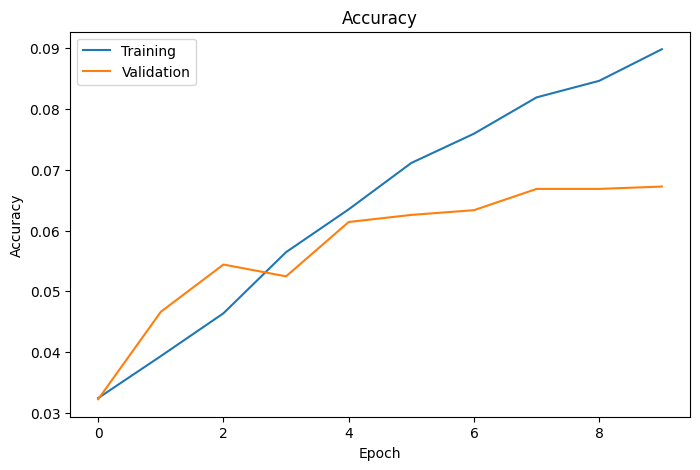

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

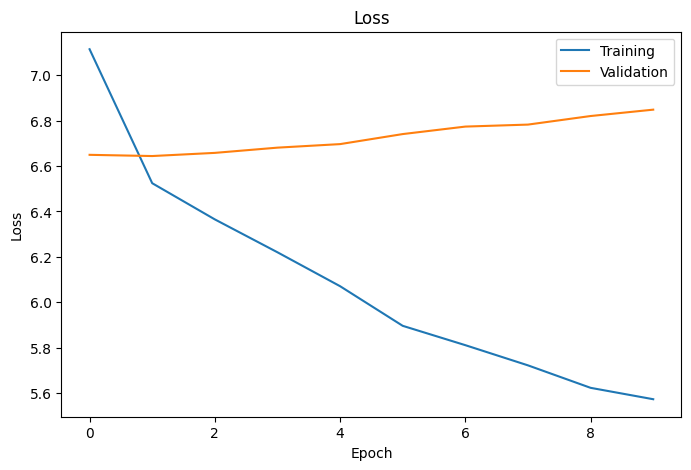

In [60]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.show()

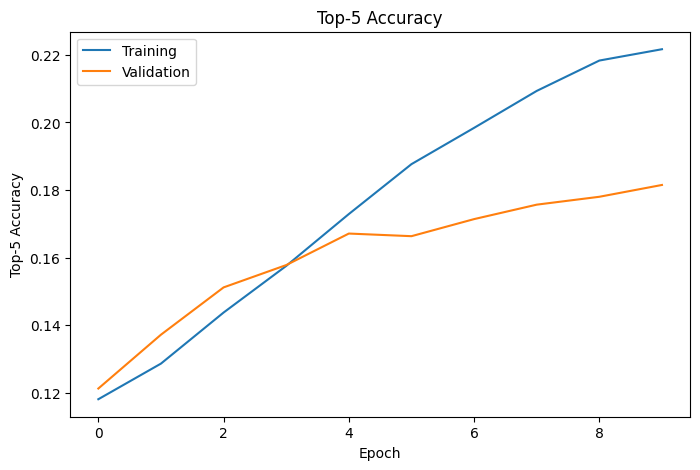

In [61]:
plt.figure(figsize=(8,5))
plt.plot(history.history['top_5_accuracy'], label='Training')
plt.plot(history.history['val_top_5_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Top-5 Accuracy')
plt.title('Top-5 Accuracy')
plt.legend()
plt.show()